# Contextual Multi-Armed Bandit with BNN-Based Quantitative Model

This notebook demonstrates the usage of a **Bayesian Neural Network (BNN) based quantitative model** for continuous action parameters with the contextual multi-armed bandit (CMAB) implementation in `pybandits`.

The BNN quantitative model maps context features and a continuous action parameter (e.g., price, dosage, bid) to a reward distribution. A Bayesian Neural Network is used to model the relationship between context, the quantitative parameter, and the expected reward, providing uncertainty estimates that support exploration–exploitation. Unlike discrete-action CMABs, this approach lets you learn and optimize over continuous or fine-grained quantitative choices while conditioning on context.

**Key aspects:**
- **Context + quantity**: The model takes both contextual features and a scalar (or vector) quantitative parameter as input.
- **Uncertainty-aware**: The BNN yields a posterior over rewards, which the bandit can use for Thompson sampling or similar strategies.
- **Flexible fitting**: Supports variational inference (VI) or other Bayesian update methods for the BNN weights.

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pybandits.cmab import CmabBernoulli
from pybandits.quantitative_model import QuantitativeBayesianNeuralNetwork

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Setup

First, we'll define actions with quantitative parameters. In this example, we'll use two actions, each with a one-dimensional quantitative parameter (e.g., price point or dosage level) ranging from 0 to 1. Unlike the SMAB model, here we also need to define contextual features.

In [ ]:
# For reproducibility
np.random.seed(42)

# Define number of features for the context
n_features = 3

# BNN options are passed through ``base_model_cold_start_kwargs`` (see ``BayesianNeuralNetwork.cold_start``).
update_kwargs = {"fit": {"n": 10000}, "optimizer_type": "adam", "learning_rate": 0.01}
dist_params_init = {"mu": 0, "sigma": 1, "nu": 5}
base_model_cold_start_kwargs = {
    "hidden_dim_list": [10],
    "update_method": "VI",
    "update_kwargs": update_kwargs,
    "dist_params_init": dist_params_init,
}

actions = {
    "action_1": QuantitativeBayesianNeuralNetwork.cold_start(
        dimension=1,
        n_features=n_features,
        base_model_cold_start_kwargs=base_model_cold_start_kwargs,
    ),
    "action_2": QuantitativeBayesianNeuralNetwork.cold_start(
        dimension=1,
        n_features=n_features,
        base_model_cold_start_kwargs=base_model_cold_start_kwargs,
    ),
}

In [17]:
actions["action_1"].bnn.update_kwargs

{'num_steps': 1000,
 'method': 'advi',
 'optimizer_type': 'adam',
 'optimizer_kwargs': {'step_size': 0.01},
 'batch_size': None,
 'early_stopping_kwargs': None,
 'restore_best_svi_state': True,
 'fit': {'n': 10000},
 'learning_rate': 0.01}

Now we can initialize the CmabBernoulli bandit with our zooming models:

In [18]:
# Initialize the bandit
cmab = CmabBernoulli(actions=actions, epsilon=1)

In [19]:
print(cmab.actions["action_1"].bnn.update_kwargs)
print(f"epsilon: {cmab.epsilon}")

{'num_steps': 1000, 'method': 'advi', 'optimizer_type': 'adam', 'optimizer_kwargs': {'step_size': 0.01}, 'batch_size': None, 'early_stopping_kwargs': None, 'restore_best_svi_state': True, 'fit': {'n': 10000}, 'learning_rate': 0.01}
epsilon: 1.0


## Simulate Environment

Let's create a reward function that depends on both the action, its quantitative parameter, and the context. For illustration purposes, we'll define that:

- `action_1` performs better when the first context feature is high and when the quantitative parameter is around 0.25
- `action_2` performs better when the second context feature is high and when the quantitative parameter is around 0.75

The reward probability follows a bell curve for the quantitative parameter and is also influenced by the context features.

In [20]:
def reward_function(action, quantity, context):
    if action == "action_1":
        # Bell curve centered at 0.25 for the quantity
        # Influenced by first context feature
        quantity_component = np.exp(-((quantity - 0.25) ** 2) / 0.02)
        context_component = 0.1 + 0.9 * (context[0] / 2)  # First feature has influence
        prob = quantity_component * context_component
    else:  # action_2
        # Bell curve centered at 0.75 for the quantity
        # Influenced by second context feature
        quantity_component = np.exp(-((quantity - 0.75) ** 2) / 0.02)
        context_component = 0.5 + 0.5 * (context[1] / 2)  # Second feature has influence
        prob = quantity_component * context_component

    # Ensure probability is between 0 and 1
    prob = max(0, min(1, prob))

    return np.random.binomial(1, prob), prob

def get_optimal_reward(context):
    max_prob_action_1 = 0.1 + 0.9 * (context[0] / 2)
    max_prob_action_2 = 0.5 + 0.5 * (context[1] / 2)
    return max(max_prob_action_1, max_prob_action_2)

Let's visualize our reward functions to understand what the bandit needs to learn. We'll show the reward surfaces for different values of context:

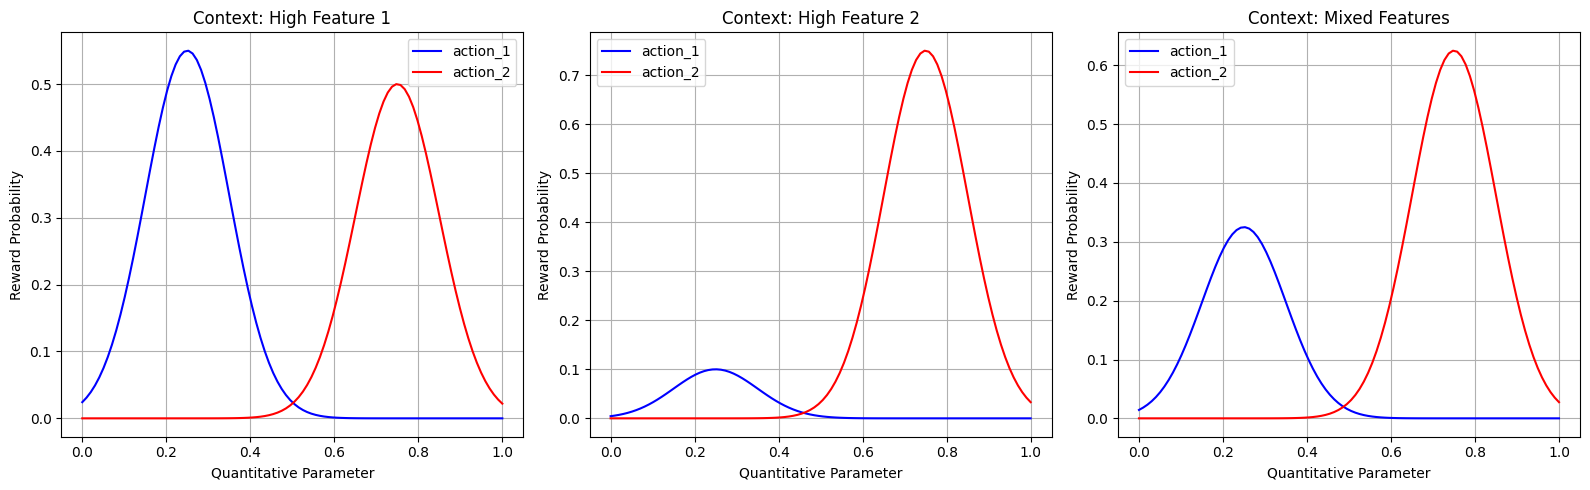

In [21]:
x = np.linspace(0, 1, 100)

# Plot for three different contexts
contexts = [
    np.array([1.0, 0.0, 0.0]),  # High first feature
    np.array([0.0, 1.0, 0.0]),  # High second feature
    np.array([0.5, 0.5, 0.0]),  # Mixed features
]

plt.figure(figsize=(16, 5))
for i, context in enumerate(contexts, 1):
    plt.subplot(1, 3, i)

    y1 = [np.exp(-((xi - 0.25) ** 2) / 0.02) * (0.1 + 0.9 * (context[0] / 2)) for xi in x]
    y2 = [np.exp(-((xi - 0.75) ** 2) / 0.02) * (0.5 + 0.5 * (context[1] / 2)) for xi in x]

    plt.plot(x, y1, "b-", label="action_1")
    plt.plot(x, y2, "r-", label="action_2")
    plt.xlabel("Quantitative Parameter")
    plt.ylabel("Reward Probability")

    if i == 1:
        title = "Context: High Feature 1"
    elif i == 2:
        title = "Context: High Feature 2"
    else:
        title = "Context: Mixed Features"

    plt.title(title)
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

## Generate Synthetic Context Data

Let's create synthetic context data for our experiment:

In [46]:
# Generate random context data
batch_sizes = [2000, 200, 200, 200, 200, 200]
context_data_sample = np.random.uniform(0, 1, (5, n_features))

# Preview the context data
pd.DataFrame(context_data_sample[:5], columns=[f"Feature {i + 1}" for i in range(n_features)])

,Feature 1,Feature 2,Feature 3
0,0.385776,0.891461,0.964794
1,0.713497,0.322929,0.493152
2,0.036585,0.810933,0.545348
3,0.017893,0.632419,0.914580
4,0.792093,0.583167,0.114180


## Bandit Training Loop

Now, let's train our bandit by simulating interactions for several rounds:

### BNN

In [47]:
for iter, batch_size in enumerate(batch_sizes):
    if iter > 0:
        cmab = CmabBernoulli(actions=actions, epsilon=0) # no exploration
    
    # Get context for this round
    current_context = np.random.uniform(0, 1, (batch_size, n_features))

    # Predict best action
    pred_actions, probs, weighted_sums = cmab.predict(context=current_context)
    chosen_actions = [a[0] for a in pred_actions]
    chosen_quantities = [a[1][0] for a in pred_actions]

    # Observe reward
    rewards_and_probs = [
        reward_function(chosen_action, chosen_quantity, _current_context)
        for chosen_action, chosen_quantity, _current_context in zip(chosen_actions, chosen_quantities, current_context)
    ]
    rewards = [reward_and_prob[0] for reward_and_prob in rewards_and_probs]
    probs = [reward_and_prob[1] for reward_and_prob in rewards_and_probs]

    optimal_probs = [get_optimal_reward(context) for context in current_context]

    regret = np.mean(np.array(optimal_probs) - np.array(probs))

    # Update bandit
    cmab.update(actions=chosen_actions, rewards=rewards, context=current_context, quantities=chosen_quantities)

    # Print progress
    print(f"Completed {iter} batches. Avg regret: {regret}")

Completed 0 batches. Avg regret: 0.38724144517801823


Completed 1 batches. Avg regret: 0.3753035156601125


Completed 2 batches. Avg regret: 0.3831157528897725


Completed 3 batches. Avg regret: 0.4103102384559053


Completed 4 batches. Avg regret: 0.4358318476105979


Completed 5 batches. Avg regret: 0.41579051438729775


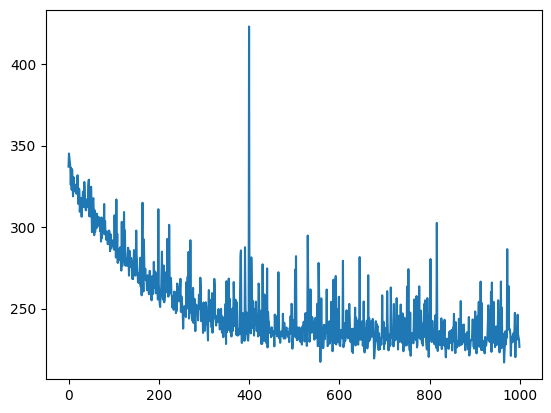

In [ ]:
plt.plot(cmab.actions["action_1"].bnn.approx_history)

In [ ]:

grid = np.mgrid[0:1:0.02, 0:1:0.02].astype(float)
grid_2d = grid.reshape(2, -1).T
num_values_per_axis = grid.shape[1]


[Text(0.5, 1.0, 'action_2'),
 Text(0, 0.5, 'Second feature'),
 Text(0.5, 0, 'Quantitative Parameter')]

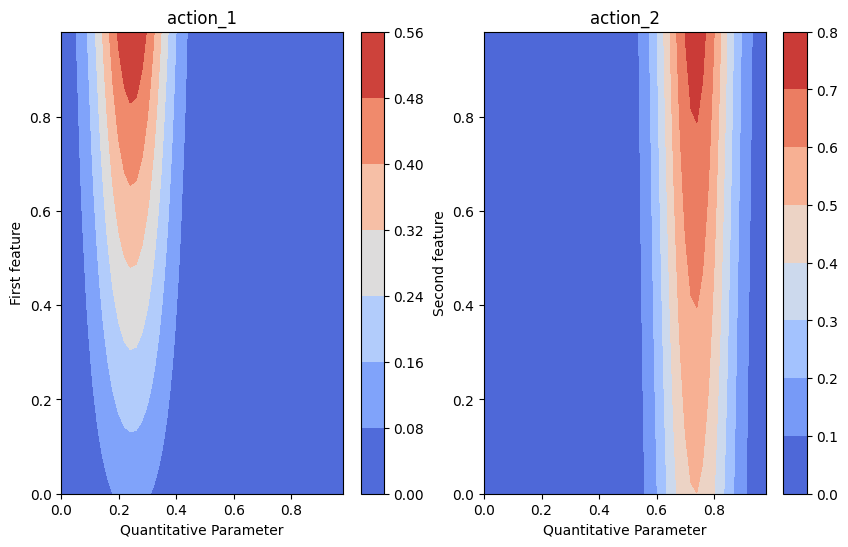

In [ ]:
plt.figure(figsize=(10, 6))
ax =plt.subplot(1, 2, 1)
y_true  = np.zeros(grid.shape[1:])
reward_prob = np.zeros(grid.shape[1:])
for i, quantity in enumerate(np.linspace(0, 1, num_values_per_axis)):
    for j, first_feature in enumerate(np.linspace(0, 1, num_values_per_axis)):
        y_true[i,j], reward_prob[i, j] = reward_function(action="action_1", quantity=quantity, context=[first_feature, 0, 0])

cmap = plt.get_cmap("coolwarm")
# Create the contour plot
contour = ax.contourf(*grid, reward_prob.reshape(num_values_per_axis, num_values_per_axis), cmap=cmap)
cbar = plt.colorbar(contour, ax=ax)
ax.set(title="action_1", ylabel="First feature", xlabel="Quantitative Parameter")
ax = plt.subplot(1, 2, 2)
y_true  = np.zeros((num_values_per_axis, num_values_per_axis))
reward_prob = np.zeros((num_values_per_axis, num_values_per_axis))
for i, quantity in enumerate(np.linspace(0, 1, num_values_per_axis)):
    for j, second_feature in enumerate(np.linspace(0, 1, num_values_per_axis)):
        y_true[i,j], reward_prob[i, j] = reward_function(action="action_2", quantity=quantity, context=[0, second_feature, 0])

cmap = plt.get_cmap("coolwarm")
# Create the contour plot
contour = ax.contourf(*grid, reward_prob.reshape(num_values_per_axis, num_values_per_axis), cmap=cmap)
cbar = plt.colorbar(contour, ax=ax)
ax.set(title="action_2", ylabel="Second feature", xlabel="Quantitative Parameter")




In [ ]:

# ``sample_proba`` takes context rows (n_features columns) and returns one (prob_fn, weight_fn) per row;
# evaluate ``prob_fn(quantity)`` with the quantity for that grid point.
n_grid = grid_2d.shape[0]
viz_rng = np.random.default_rng(123)

context_grid_action_1 = np.column_stack([grid_2d[:, 1], np.zeros(n_grid), np.zeros(n_grid)])
batch_proba_action_1 = []
for _ in range(500):
    prob_weight_list = cmab.actions["action_1"].sample_proba(context=context_grid_action_1, rng=viz_rng)
    batch_proba_action_1.append(
        np.array([pw[0](float(q)) for q, pw in zip(grid_2d[:, 0], prob_weight_list)])
    )
batch_proba_action_1 = np.array(batch_proba_action_1)

context_grid_action_2 = np.column_stack([np.zeros(n_grid), grid_2d[:, 1], np.zeros(n_grid)])
batch_proba_action_2 = []
for _ in range(50):
    prob_weight_list = cmab.actions["action_2"].sample_proba(context=context_grid_action_2, rng=viz_rng)
    batch_proba_action_2.append(
        np.array([pw[0](float(q)) for q, pw in zip(grid_2d[:, 0], prob_weight_list)])
    )
batch_proba_action_2 = np.array(batch_proba_action_2)


[Text(0.5, 1.0, 'action_1 — posterior mean P(reward)'),
 Text(0, 0.5, 'First feature'),
 Text(0.5, 0, 'Quantitative Parameter')]

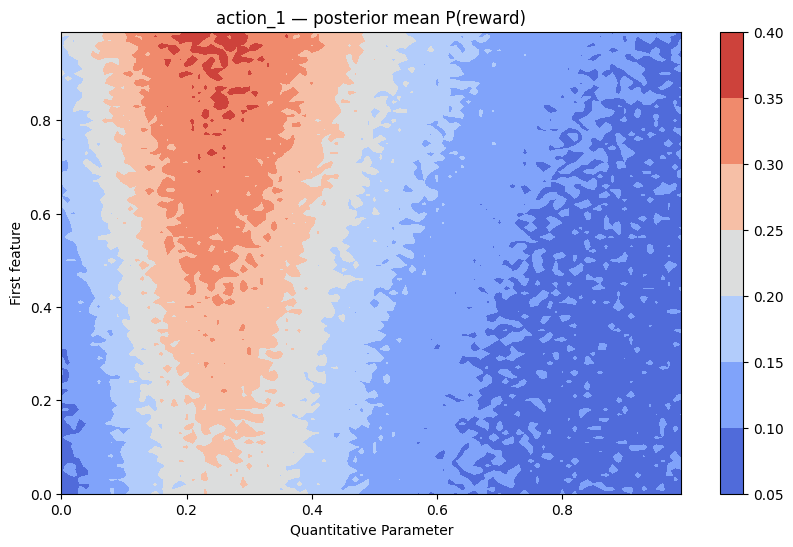

In [ ]:
pred_proba_mean = batch_proba_action_1.mean(axis=0)

cmap = plt.get_cmap("coolwarm")

fig, ax = plt.subplots(figsize=(10, 6))

# Posterior mean surface for action_1 (same axes as the left ground-truth panel)
contour = ax.contourf(*grid, pred_proba_mean.reshape(100, 100), cmap=cmap)
cbar = plt.colorbar(contour, ax=ax)
ax.set(title="action_1 — posterior mean P(reward)", ylabel="First feature", xlabel="Quantitative Parameter")

In [ ]:
# cmab.actions["action_1"]  # quantitative model wrapper; underlying BNN: cmab.actions["action_1"].bnn

## Testing with Specific Contexts

Finally, let's test our trained bandit with specific contexts to see if it has learned the optimal policy:

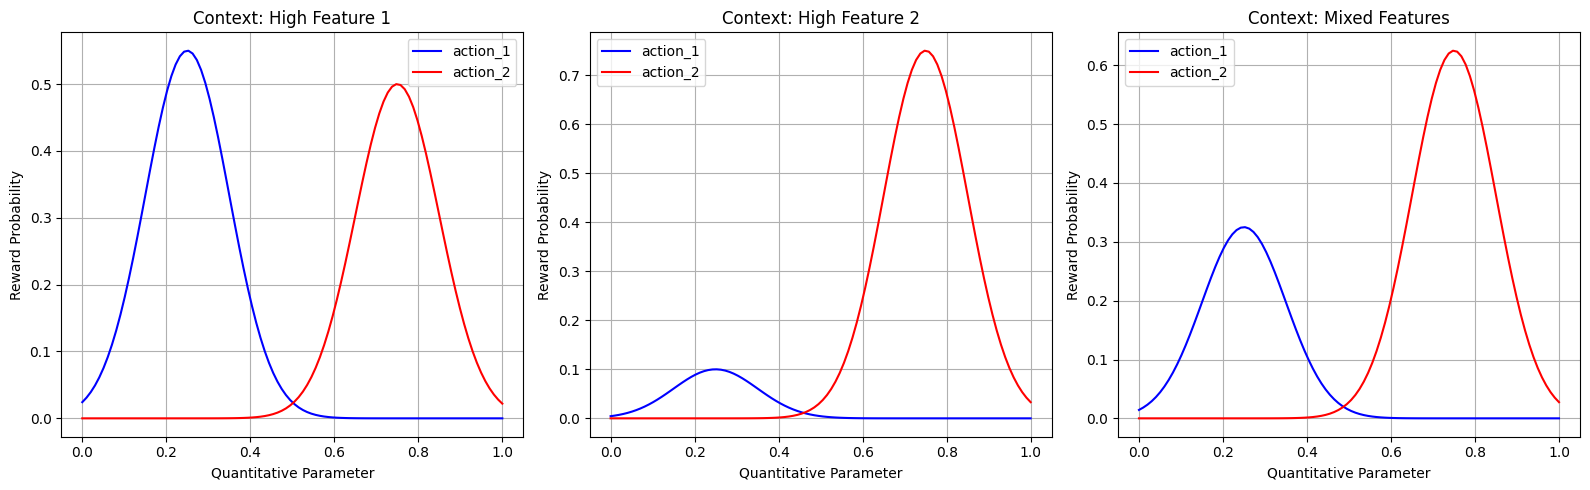

In [ ]:
x = np.linspace(0, 1, 100)

plt.figure(figsize=(16, 5))
for i, context in enumerate(contexts, 1):
    plt.subplot(1, 3, i)

    y1 = [np.exp(-((xi - 0.25) ** 2) / 0.02) * (0.1 + 0.9 * (context[0] / 2)) for xi in x]
    y2 = [np.exp(-((xi - 0.75) ** 2) / 0.02) * (0.5 + 0.5 * (context[1] / 2)) for xi in x]

    plt.plot(x, y1, "b-", label="action_1")
    plt.plot(x, y2, "r-", label="action_2")
    plt.xlabel("Quantitative Parameter")
    plt.ylabel("Reward Probability")

    if i == 1:
        title = "Context: High Feature 1"
    elif i == 2:
        title = "Context: High Feature 2"
    else:
        title = "Context: Mixed Features"

    plt.title(title)
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Define test contexts
test_contexts = np.array(
    [
        [1.0, 0.0, 0.0],  # High feature 1, low feature 2
        [0.0, 1.0, 0.0],  # Low feature 1, high feature 2
        [1.0, 1.0, 0.0],  # High feature 1 and 2
        [0.0, 0.0, 0.0],  # Low feature 1 and 2
    ]
)

# Test predictions
results = []
for i, context in enumerate(test_contexts):
    context_reshaped = context.reshape(1, -1)
    pred_actions, probs, weighted_sums = cmab.predict(context=context_reshaped)
    chosen_action_quantity = pred_actions[0]
    chosen_action = chosen_action_quantity[0]
    chosen_quantities = chosen_action_quantity[1][0]
    chosen_action_probs = probs[0][chosen_action](chosen_quantities)

    # Sample optimal quantity for the chosen action
    # In a real application, you would have a method to test different quantities
    # Here we'll use our knowledge of the true optimal values
    if chosen_action == "action_1":
        optimal_quantity = 0.25
    else:
        optimal_quantity = 0.75

    # Expected reward probability
    expected_reward = reward_function(chosen_action, optimal_quantity, context)

    results.append(
        {
            "Context": context,
            "Chosen Action": chosen_action,
            "Chosen Qunatity": chosen_quantities,
            "Action Probabilities": chosen_action_probs,
            "Optimal Quantity": optimal_quantity,
            "Expected Reward": expected_reward,
        }
    )

# Display results
for i, result in enumerate(results):
    context_type = ""
    if i == 0:
        context_type = "High feature 1, low feature 2"
    elif i == 1:
        context_type = "Low feature 1, high feature 2"
    elif i == 2:
        context_type = "High feature 1 and 2"
    elif i == 3:
        context_type = "Low feature 1 and 2"

    print(f"\nTest {i + 1}: {context_type}")
    print(f"Context: {result['Context']}")
    print(f"Chosen Action: {result['Chosen Action']}")
    print(f"Chosen Quantity: {result['Chosen Qunatity']}")
    print(f"Action Probabilities: {result['Action Probabilities']}")
    print(f"Optimal Quantity: {result['Optimal Quantity']:.2f}")
    print(f"Expected Reward: {result['Expected Reward']}")


Test 1: High feature 1, low feature 2
Context: [1. 0. 0.]
Chosen Action: action_2
Chosen Quantity: 0.9999997944215839
Action Probabilities: 0.038810425722199796
Optimal Quantity: 0.75
Expected Reward: (0, 0.5)

Test 2: Low feature 1, high feature 2
Context: [0. 1. 0.]
Chosen Action: action_2
Chosen Quantity: 0.9132489432822471
Action Probabilities: 0.9731637421930661
Optimal Quantity: 0.75
Expected Reward: (1, 0.75)

Test 3: High feature 1 and 2
Context: [1. 1. 0.]
Chosen Action: action_2
Chosen Quantity: 0.999995859636362
Action Probabilities: 0.9964535898586978
Optimal Quantity: 0.75
Expected Reward: (1, 0.75)

Test 4: Low feature 1 and 2
Context: [0. 0. 0.]
Chosen Action: action_2
Chosen Quantity: 0.7690344233938914
Action Probabilities: 0.8811860685177564
Optimal Quantity: 0.75
Expected Reward: (1, 0.5)


## Conclusion

The CMAB BNN-based quantitative model uses a Bayesian Neural Network to map context and continuous action parameters to reward distributions. This approach enables efficient exploration and exploitation of continuous or fine-grained action parameters while conditioning on context. The BNN provides uncertainty estimates (e.g., via variational inference) that the bandit uses for Thompson sampling or similar strategies, balancing exploration of uncertain regions with exploitation of high predicted rewards.

This approach is particularly useful when:
1. Actions have continuous parameters (e.g., price, dosage, bid) that affect rewards
2. The reward function depends on both context and action parameters
3. The optimal parameter values may vary across different contexts
4. You want a single differentiable model (BNN) over the full parameter space rather than adaptive discretization

Real-world applications include:
- **Personalized pricing**: Find optimal prices (continuous parameter) based on customer features (context)
- **Content recommendation**: Optimize content parameters (e.g., length, complexity) based on user demographics
- **Medical dosing**: Determine optimal medication dosages based on patient characteristics
- **Ad campaign optimization**: Find best bid values based on ad placement and target audience